# Test-Set One-Step Forecasts (Annotated)

This notebook takes a **train set** and a **test set**, applies the **same transformations** used in the original modeling notebook, and then produces **one-step-ahead predictions** on the test horizon using:

1. **SARIMAX (2, 0, 1)**
2. **MLP**
3. **RNN / GRU**
4. **1D CNN**

### Forecasting protocol used here
- Transformation parameters are **fit on the train set**.
- The same fitted transformations are then **applied to train + test** so that lagged values for the first test point are available.
- Every prediction on the test set is made as a **one-step-ahead forecast**.
- For the deep-learning models, the networks are **trained on the train set only**.
- The notebook reports **RMSE** and **MAE** on the final test horizon.


In [15]:
# Optional: uncomment and run this cell if your environment is missing packages.
# %pip install numpy pandas matplotlib scipy scikit-learn statsmodels torch

## 1. Imports, reproducibility, and file paths

Edit the two paths below if your train and test CSV files live somewhere else.

In [16]:
from pathlib import Path
import random
import warnings

from IPython.display import display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import boxcox
from scipy.special import boxcox as boxcox_with_lambda, inv_boxcox

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

from statsmodels.tsa.statespace.sarimax import SARIMAX

import torch
import torch.nn as nn
import torch.optim as optim

warnings.filterwarnings("ignore")

SEED = 112
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# -----------------------------
# File paths
# -----------------------------
TRAIN_PATH = Path("../Data/train.csv")
TEST_PATH = Path("../Data/test.csv")

# -----------------------------
# Column names
# -----------------------------
DATE_COL = "Month"
TARGET_COL = "int_rate_mean"
TREASURY_COL = "Treasury_data"

# -----------------------------
# Transformation / feature setup
# -----------------------------
TARGET_LAGS = [1, 3, 4]
TREASURY_LAG = 1
TARGET_DIFF2_COL = "target_diff2"
FEATURE_COLS = [f"target_lag_{lag}" for lag in TARGET_LAGS] + ["treasury_lag_1"]
SEQUENCE_FEATURE_COLS = [TARGET_DIFF2_COL, "treasury_lag_1"]

# -----------------------------
# Fixed model choices from the original notebook
# -----------------------------
SARIMAX_ORDER = (2, 0, 1)

MLP_PARAMS = {
    "hidden_dim": 24,
    "dropout": 0.378016,
    "lr": 0.007305,
    "max_epochs": 150,
}

RNN_PARAMS = {
    "rnn_type": "LSTM",
    "seq_length": 5,
    "hidden_dim": 4,
    "lr": 0.021783,
    "max_epochs": 150,
    "patience": 15,
}

CNN_PARAMS = {
    "seq_length": 4,
    "kernel_size": 2,
    "num_filters": 12,
    "lr": 0.014647,
    "max_epochs": 150,
    "patience": 15,
}

## 2. Load the train and test sets

The code below expects both CSV files to contain the date column, the target column, and the treasury column.

In [17]:
def load_dataset(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df[DATE_COL] = pd.to_datetime(df[DATE_COL])
    df = df.sort_values(DATE_COL).reset_index(drop=True)
    return df

train_raw = load_dataset(TRAIN_PATH)
test_raw = load_dataset(TEST_PATH)

print(f"Train shape: {train_raw.shape}")
print(f"Test shape:  {test_raw.shape}")
print(f"Train range: {train_raw[DATE_COL].min().date()} -> {train_raw[DATE_COL].max().date()}")
print(f"Test range:  {test_raw[DATE_COL].min().date()} -> {test_raw[DATE_COL].max().date()}")

display(train_raw.head())
display(test_raw.head())

Train shape: (104, 9)
Test shape:  (35, 9)
Train range: 2007-06-01 -> 2016-01-01
Test range:  2016-02-01 -> 2018-12-01


,Month,int_rate_mean,int_rate_median,int_rate_std,loan_amnt_sum,loan_amnt_mean,loan_amnt_count,Treasury_data,fed_rate
0,2007-06-01,9.814583,9.640,1.886434,91850.0,3827.083333,24,4.61,5.25
1,2007-07-01,11.158571,10.590,2.830279,348325.0,5528.968254,63,4.82,5.26
2,2007-08-01,11.543514,11.065,3.116487,515300.0,6963.513514,74,4.20,5.02
3,2007-09-01,12.463208,11.860,3.157293,372950.0,7036.792453,53,3.89,4.94
4,2007-10-01,12.438476,12.490,2.698128,753225.0,7173.571429,105,3.90,4.76


,Month,int_rate_mean,int_rate_median,int_rate_std,loan_amnt_sum,loan_amnt_mean,loan_amnt_count,Treasury_data,fed_rate
0,2016-02-01,12.547103,11.99,4.729836,619446250.0,15670.678489,39529,0.31,0.38
1,2016-03-01,12.526671,11.99,5.044473,949367550.0,15314.355885,61992,0.29,0.36
2,2016-04-01,12.429358,11.99,4.973028,537278275.0,14747.427399,36432,0.23,0.37
3,2016-05-01,12.503870,11.47,4.965179,417538850.0,14700.519311,28403,0.27,0.37
4,2016-06-01,12.509503,11.47,4.851728,488623850.0,14798.263121,33019,0.27,0.38


## 3. Fit the train-time transformations and apply them to the combined series

The original notebook used:
- **Box-Cox + first difference + second difference** for the target
- **log + first difference** for treasury

To score the test set correctly, we:
1. fit the Box-Cox lambda and shifts on the **train set**
2. apply those same fitted values to **train + test**
3. create lagged features on the combined transformed series

This preserves the one-step-ahead structure while avoiding test-time retuning.

In [18]:
def compute_positive_shift(series: pd.Series, buffer: float = 0.0) -> float:
    minimum = series.min()
    return max(0.0, -minimum + buffer)

def prepare_transformed_timeseries(train_df: pd.DataFrame, test_df: pd.DataFrame):
    train_ts = (
        train_df[[DATE_COL, TARGET_COL, TREASURY_COL]]
        .copy()
        .set_index(DATE_COL)
        .sort_index()
    )
    test_ts = (
        test_df[[DATE_COL, TARGET_COL, TREASURY_COL]]
        .copy()
        .set_index(DATE_COL)
        .sort_index()
    )

    combined_ts = pd.concat([train_ts, test_ts], axis=0).sort_index()

    # Fit train-only transformation parameters.
    target_shift = compute_positive_shift(train_ts[TARGET_COL])
    treasury_shift = compute_positive_shift(train_ts[TREASURY_COL], buffer=0.1)

    # Safety checks: Box-Cox and log require positivity after shifting.
    if ((combined_ts[TARGET_COL] + target_shift) <= 0).any():
        raise ValueError(
            "The train-fitted Box-Cox shift is not large enough for some test values. "
            "Please inspect the target series or switch to a transform that can handle non-positive values."
        )
    if ((combined_ts[TREASURY_COL] + treasury_shift) <= 0).any():
        raise ValueError(
            "The train-fitted treasury log shift is not large enough for some test values."
        )

    # Fit Box-Cox lambda on train only, then apply the same lambda everywhere.
    train_target_positive = train_ts[TARGET_COL] + target_shift
    _, target_lambda = boxcox(train_target_positive)

    combined_ts["target_boxcox"] = boxcox_with_lambda(combined_ts[TARGET_COL] + target_shift, target_lambda)
    combined_ts["target_diff1"] = combined_ts["target_boxcox"].diff(1)
    combined_ts["target_diff2"] = combined_ts["target_boxcox"].diff(1).diff(1)

    combined_ts["treasury_shifted"] = combined_ts[TREASURY_COL] + treasury_shift
    combined_ts["treasury_log"] = np.log(combined_ts["treasury_shifted"])
    combined_ts["treasury_log_diff"] = combined_ts["treasury_log"].diff(1)

    transform_info = {
        "target_shift": float(target_shift),
        "target_lambda": float(target_lambda),
        "treasury_shift": float(treasury_shift),
    }
    return train_ts, test_ts, combined_ts, transform_info

train_ts, test_ts, combined_ts, transform_info = prepare_transformed_timeseries(train_raw, test_raw)

print("Fitted transformation parameters:")
for k, v in transform_info.items():
    print(f"  {k}: {v:.6f}")

combined_ts[[TARGET_COL, "target_boxcox", "target_diff1", "target_diff2", TREASURY_COL, "treasury_log_diff"]].tail()

Fitted transformation parameters:
  target_shift: 0.000000
  target_lambda: -0.177860
  treasury_shift: 0.090000


,int_rate_mean,target_boxcox,target_diff1,target_diff2,Treasury_data,treasury_log_diff
Month,,,,,,
2018-08-01,12.988657,2.059012,-0.004485,-0.030248,2.03,0.033576
2018-09-01,12.779897,2.048728,-0.010284,-0.005799,2.13,0.046091
2018-10-01,12.749912,2.047234,-0.001493,0.008791,2.25,0.052644
2018-11-01,13.081592,2.063527,0.016293,0.017787,2.33,0.033617
2018-12-01,12.980739,2.058625,-0.004902,-0.021196,2.37,0.016394


## 4. Build the supervised modeling frames

These are the same core lag features used in the original notebook:
- target second-difference lags: **1, 3, 4**
- treasury log-difference lag: **1**

We also keep the reconstruction anchors:
- previous first difference
- previous Box-Cox level

In [19]:
def create_modeling_frame(ts_frame: pd.DataFrame) -> pd.DataFrame:
    frame = pd.DataFrame(index=ts_frame.index)

    frame[TARGET_DIFF2_COL] = ts_frame["target_diff2"]

    for lag in TARGET_LAGS:
        frame[f"target_lag_{lag}"] = frame[TARGET_DIFF2_COL].shift(lag)

    frame["treasury_lag_1"] = ts_frame["treasury_log_diff"].shift(TREASURY_LAG)
    frame["prev_diff1"] = ts_frame["target_diff1"].shift(1)
    frame["prev_boxcox"] = ts_frame["target_boxcox"].shift(1)

    return frame.dropna()

combined_model = create_modeling_frame(combined_ts)

train_end_date = train_ts.index.max()
train_model = combined_model.loc[combined_model.index <= train_end_date].copy()
test_model = combined_model.loc[combined_model.index > train_end_date].copy()

print(f"Train modeling frame shape: {train_model.shape}")
print(f"Test modeling frame shape:  {test_model.shape}")

display(train_model.head())
display(test_model.head())

Train modeling frame shape: (98, 7)
Test modeling frame shape:  (35, 7)


,target_diff2,target_lag_1,target_lag_3,target_lag_4,treasury_lag_1,prev_diff1,prev_boxcox
Month,,,,,,,
2007-12-01,0.016794,-0.023748,0.027260,-0.062510,-0.171850,-0.025016,2.006458
2008-01-01,0.003281,0.016794,-0.050546,0.027260,-0.083770,-0.008223,1.998235
2008-02-01,0.030522,0.003281,-0.023748,-0.050546,-0.084367,-0.004941,1.993294
2008-03-01,-0.019838,0.030522,0.016794,-0.023748,-0.250812,0.025580,2.018874
2008-04-01,-0.001845,-0.019838,0.003281,0.016794,-0.492888,0.005743,2.024617


,target_diff2,target_lag_1,target_lag_3,target_lag_4,treasury_lag_1,prev_diff1,prev_boxcox
Month,,,,,,,
2016-02-01,0.012680,-0.005212,0.013444,-0.022669,0.089612,0.000542,2.023802
2016-03-01,-0.014261,0.012680,0.011593,0.013444,0.133531,0.013222,2.037024
2016-04-01,-0.003939,-0.014261,-0.005212,0.011593,-0.051293,-0.001039,2.035984
2016-05-01,0.008794,-0.003939,0.012680,-0.005212,-0.171850,-0.004978,2.031006
2016-06-01,-0.003528,0.008794,-0.014261,0.012680,0.117783,0.003816,2.034822


## 5. Shared utilities for reconstruction, metrics, and plots

In [20]:
def inverse_boxcox_to_original(boxcox_value: float, boxcox_lambda: float, boxcox_shift: float = 0.0) -> float:
    return inv_boxcox(boxcox_value, boxcox_lambda) - boxcox_shift

def reconstruct_prediction(pred_diff2: float, anchor_row: pd.Series, transform_info: dict) -> float:
    pred_boxcox = pred_diff2 + anchor_row["prev_diff1"] + anchor_row["prev_boxcox"]
    return inverse_boxcox_to_original(
        pred_boxcox,
        transform_info["target_lambda"],
        transform_info["target_shift"],
    )

def summarize_forecasts(results: pd.DataFrame) -> dict:
    return {
        "RMSE": float(np.sqrt(mean_squared_error(results["actual"], results["prediction"]))),
        "MAE": float(mean_absolute_error(results["actual"], results["prediction"])),
        "n_forecasts": int(len(results)),
    }

def make_forecast_df(dates, actuals, preds, model_name: str) -> pd.DataFrame:
    return pd.DataFrame(
        {
            "date": pd.to_datetime(dates),
            "actual": np.asarray(actuals, dtype=float),
            "prediction": np.asarray(preds, dtype=float),
            "model": model_name,
        }
    )

def plot_predictions(results: pd.DataFrame, title: str) -> None:
    plot_df = results.sort_values("date").copy()
    plt.figure(figsize=(12, 4))
    plt.plot(plot_df["date"], plot_df["actual"], marker="o", label="Actual")
    plt.plot(plot_df["date"], plot_df["prediction"], marker="o", label="Prediction")
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel(TARGET_COL)
    plt.legend()
    plt.tight_layout()
    plt.show()

## 6. SARIMAX (2, 0, 1)

We fit the SARIMAX parameters on the **train transformed target** only, with the lagged treasury feature as the exogenous regressor.
Then we move through the test set one step at a time:
1. forecast the next transformed target difference
2. reconstruct back to the original scale
3. append the **observed** transformed test value to update the state for the next step

,date,actual,prediction,model
0,2016-02-01,12.547103,12.287217,"SARIMAX(2,0,1)"
1,2016-03-01,12.526671,12.578387,"SARIMAX(2,0,1)"
2,2016-04-01,12.429358,12.518403,"SARIMAX(2,0,1)"
3,2016-05-01,12.503870,12.425694,"SARIMAX(2,0,1)"
4,2016-06-01,12.509503,12.522633,"SARIMAX(2,0,1)"


{'RMSE': 0.31354079425398207, 'MAE': 0.22034902310371493, 'n_forecasts': 35}


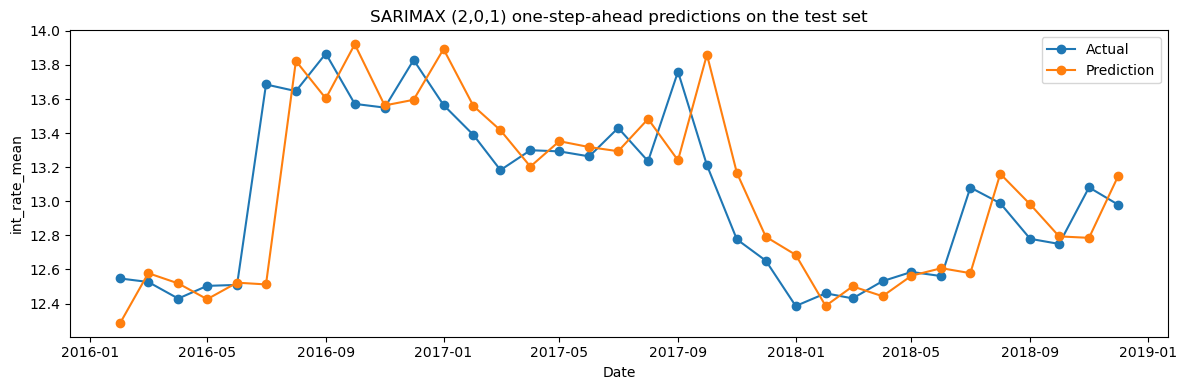

In [21]:
def _extract_scalar_forecast(forecast_output) -> float:
    """Return the first forecast value regardless of statsmodels return type."""
    if isinstance(forecast_output, pd.DataFrame):
        return float(forecast_output.iloc[0, 0])
    if isinstance(forecast_output, pd.Series):
        return float(forecast_output.iloc[0])
    arr = np.asarray(forecast_output).reshape(-1)
    return float(arr[0])


def sarimax_one_step_forecast(
    train_frame: pd.DataFrame,
    test_frame: pd.DataFrame,
    combined_ts: pd.DataFrame,
    order: tuple[int, int, int],
    transform_info: dict,
) -> pd.DataFrame:
    exog_cols = ["treasury_lag_1"]

    model = SARIMAX(
        endog=train_frame[[TARGET_DIFF2_COL]],   # keep as 1-column DataFrame for consistency
        exog=train_frame[exog_cols],
        order=order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    fitted = model.fit(disp=False)

    records = []

    for date in test_frame.index:
        # Keep exogenous input as a 1-row DataFrame with the exact same columns
        exog_row = pd.DataFrame(
            test_frame.loc[date, exog_cols].values.reshape(1, -1),
            index=pd.Index([date], name=test_frame.index.name),
            columns=exog_cols,
        )

        forecast_output = fitted.forecast(steps=1, exog=exog_row)
        pred_diff2 = _extract_scalar_forecast(forecast_output)

        anchor_row = test_frame.loc[date]
        prediction = reconstruct_prediction(pred_diff2, anchor_row, transform_info)
        actual = float(combined_ts.loc[date, TARGET_COL])

        records.append(
            {
                "date": date,
                "actual": actual,
                "prediction": float(prediction),
                "model": "SARIMAX(2,0,1)",
            }
        )

        observed_endog = pd.DataFrame(
            {TARGET_DIFF2_COL: [float(test_frame.loc[date, TARGET_DIFF2_COL])]},
            index=pd.Index([date], name=test_frame.index.name),
        )

        fitted = fitted.append(endog=observed_endog, exog=exog_row, refit=False)

    return pd.DataFrame(records)


sarimax_results = sarimax_one_step_forecast(
    train_frame=train_model,
    test_frame=test_model,
    combined_ts=combined_ts,
    order=SARIMAX_ORDER,
    transform_info=transform_info,
)

display(sarimax_results.head())
print(summarize_forecasts(sarimax_results))
plot_predictions(sarimax_results, "SARIMAX (2,0,1) one-step-ahead predictions on the test set")


## 7. Deep learning helper classes and training utilities

These classes match the compact architectures used in the original notebook:
- a small **MLP**
- a small **GRU/LSTM** wrapper
- a compact **1D CNN**

In [22]:
def clone_state_dict(model: nn.Module) -> dict:
    return {name: tensor.detach().clone() for name, tensor in model.state_dict().items()}

def create_sequences(X_data: np.ndarray, y_data: np.ndarray, seq_length: int):
    X_seq, y_seq = [], []
    for start_idx in range(len(X_data) - seq_length):
        end_idx = start_idx + seq_length
        X_seq.append(X_data[start_idx:end_idx])
        y_seq.append(y_data[end_idx])
    return np.array(X_seq), np.array(y_seq)

def train_torch_model(
    model: nn.Module,
    X_train: torch.Tensor,
    y_train: torch.Tensor,
    optimizer: optim.Optimizer,
    loss_fn,
    max_epochs: int,
    X_val: torch.Tensor | None = None,
    y_val: torch.Tensor | None = None,
    patience: int | None = None,
) -> nn.Module:
    best_state = None
    best_val_loss = float("inf")
    epochs_without_improvement = 0

    for _ in range(max_epochs):
        model.train()
        optimizer.zero_grad()
        train_output = model(X_train)
        train_loss = loss_fn(train_output, y_train)
        train_loss.backward()
        optimizer.step()

        if X_val is None or y_val is None:
            continue

        model.eval()
        with torch.no_grad():
            val_output = model(X_val)
            val_loss = loss_fn(val_output, y_val).item()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = clone_state_dict(model)
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if patience is not None and epochs_without_improvement >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model

class DynamicMLP(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, dropout_prob: float):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)

class TinyRNN(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, rnn_type: str):
        super().__init__()
        if rnn_type == "GRU":
            self.recurrent = nn.GRU(input_dim, hidden_dim, num_layers=1, batch_first=True)
            self.is_lstm = False
        else:
            self.recurrent = nn.LSTM(input_dim, hidden_dim, num_layers=1, batch_first=True)
            self.is_lstm = True
        self.output = nn.Linear(hidden_dim, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        _, hidden = self.recurrent(x)
        if self.is_lstm:
            hidden = hidden[0]
        last_hidden = hidden[-1]
        return self.output(last_hidden)

class Tiny1DCNN(nn.Module):
    def __init__(self, input_dim: int, num_filters: int, kernel_size: int, seq_length: int):
        super().__init__()
        conv_output_length = seq_length - kernel_size + 1
        self.conv = nn.Conv1d(input_dim, num_filters, kernel_size=kernel_size)
        self.relu = nn.ReLU()
        self.output = nn.Linear(num_filters * conv_output_length, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.transpose(1, 2)
        x = self.relu(self.conv(x))
        x = x.reshape(x.size(0), -1)
        return self.output(x)

## 8. MLP

This model uses the tabular lag features directly:
- `target_lag_1`
- `target_lag_3`
- `target_lag_4`
- `treasury_lag_1`

We reuse the best hyperparameters found in the original notebook and then fit once on the full train modeling frame.

,date,actual,prediction,model
0,2016-02-01,12.547103,12.444110,MLP
1,2016-03-01,12.526671,12.591167,MLP
2,2016-04-01,12.429358,12.625733,MLP
3,2016-05-01,12.503870,12.283671,MLP
4,2016-06-01,12.509503,12.580862,MLP


{'RMSE': 0.3595378316715902, 'MAE': 0.2735062509502421, 'n_forecasts': 35}


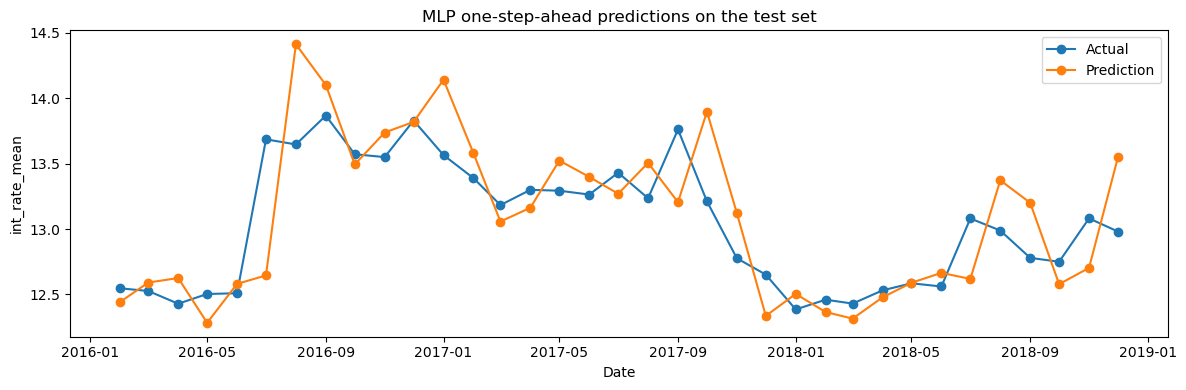

In [23]:
def fit_mlp(train_frame: pd.DataFrame, params: dict):
    scaler = StandardScaler()
    X_train = scaler.fit_transform(train_frame[FEATURE_COLS])
    y_train = train_frame[TARGET_DIFF2_COL].to_numpy().reshape(-1, 1)

    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.float32)

    model = DynamicMLP(
        input_dim=X_train_t.shape[1],
        hidden_dim=params["hidden_dim"],
        dropout_prob=params["dropout"],
    )
    optimizer = optim.Adam(model.parameters(), lr=params["lr"])
    loss_fn = nn.MSELoss()

    model = train_torch_model(
        model=model,
        X_train=X_train_t,
        y_train=y_train_t,
        optimizer=optimizer,
        loss_fn=loss_fn,
        max_epochs=params["max_epochs"],
    )
    return model, scaler

def mlp_one_step_forecast(
    train_frame: pd.DataFrame,
    test_frame: pd.DataFrame,
    combined_ts: pd.DataFrame,
    transform_info: dict,
    params: dict,
) -> pd.DataFrame:
    model, scaler = fit_mlp(train_frame, params)

    X_test = scaler.transform(test_frame[FEATURE_COLS])
    X_test_t = torch.tensor(X_test, dtype=torch.float32)

    model.eval()
    with torch.no_grad():
        pred_diff2 = model(X_test_t).cpu().numpy().reshape(-1)

    preds = []
    actuals = []

    for date, pred_d2 in zip(test_frame.index, pred_diff2):
        anchor_row = test_frame.loc[date]
        prediction = reconstruct_prediction(float(pred_d2), anchor_row, transform_info)
        preds.append(float(prediction))
        actuals.append(float(combined_ts.loc[date, TARGET_COL]))

    return make_forecast_df(test_frame.index, actuals, preds, "MLP")

mlp_results = mlp_one_step_forecast(
    train_frame=train_model,
    test_frame=test_model,
    combined_ts=combined_ts,
    transform_info=transform_info,
    params=MLP_PARAMS,
)

display(mlp_results.head())
print(summarize_forecasts(mlp_results))
plot_predictions(mlp_results, "MLP one-step-ahead predictions on the test set")

## 9. RNN / GRU

This model consumes short rolling sequences built from:
- `target_diff2`
- `treasury_lag_1`

For consistency with the original notebook, we keep a small validation tail from the train set for early stopping.

,date,actual,prediction,model
0,2016-02-01,12.547103,12.431097,RNN_GRU
1,2016-03-01,12.526671,12.791974,RNN_GRU
2,2016-04-01,12.429358,12.817639,RNN_GRU
3,2016-05-01,12.503870,12.745816,RNN_GRU
4,2016-06-01,12.509503,12.736329,RNN_GRU


{'RMSE': 0.3820192600839475, 'MAE': 0.2968136115227403, 'n_forecasts': 35}


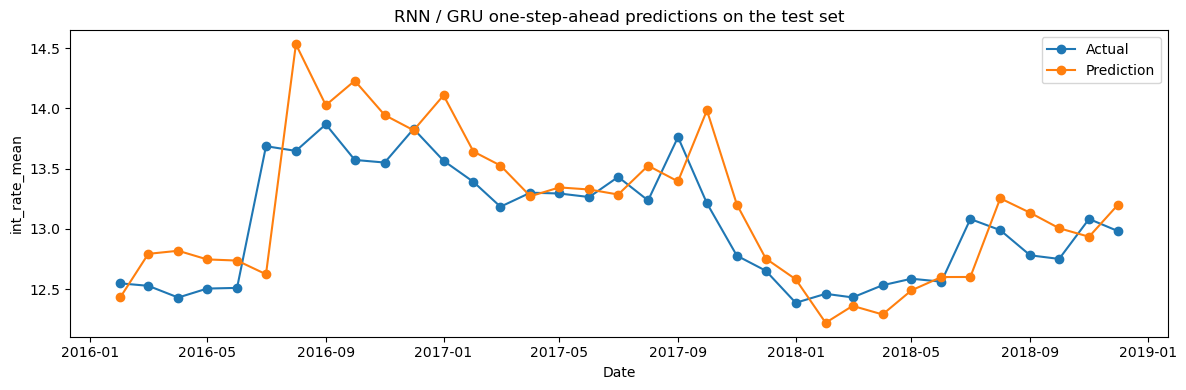

In [24]:
def fit_rnn(train_frame: pd.DataFrame, params: dict):
    seq_length = params["seq_length"]

    if len(train_frame) <= seq_length + 2:
        raise ValueError("The train modeling frame is too short for the requested RNN sequence length.")

    split_idx = int(len(train_frame) * 0.85)
    train_split = train_frame.iloc[:split_idx].copy()
    val_split = train_frame.iloc[split_idx:].copy()

    if len(train_split) <= seq_length or len(val_split) <= seq_length:
        raise ValueError("Not enough rows in the train split / validation split for RNN sequence creation.")

    X_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_train = X_scaler.fit_transform(train_split[SEQUENCE_FEATURE_COLS])
    y_train = y_scaler.fit_transform(train_split[[TARGET_DIFF2_COL]])
    X_val = X_scaler.transform(val_split[SEQUENCE_FEATURE_COLS])
    y_val = y_scaler.transform(val_split[[TARGET_DIFF2_COL]])

    X_train_seq, y_train_seq = create_sequences(X_train, y_train, seq_length)
    X_val_seq, y_val_seq = create_sequences(X_val, y_val, seq_length)

    X_train_t = torch.tensor(X_train_seq, dtype=torch.float32)
    y_train_t = torch.tensor(y_train_seq.reshape(-1, 1), dtype=torch.float32)
    X_val_t = torch.tensor(X_val_seq, dtype=torch.float32)
    y_val_t = torch.tensor(y_val_seq.reshape(-1, 1), dtype=torch.float32)

    model = TinyRNN(
        input_dim=X_train_t.shape[2],
        hidden_dim=params["hidden_dim"],
        rnn_type=params["rnn_type"],
    )
    optimizer = optim.Adam(model.parameters(), lr=params["lr"])
    loss_fn = nn.HuberLoss()

    model = train_torch_model(
        model=model,
        X_train=X_train_t,
        y_train=y_train_t,
        X_val=X_val_t,
        y_val=y_val_t,
        optimizer=optimizer,
        loss_fn=loss_fn,
        max_epochs=params["max_epochs"],
        patience=params["patience"],
    )
    return model, X_scaler, y_scaler

def rnn_one_step_forecast(
    train_frame: pd.DataFrame,
    test_frame: pd.DataFrame,
    combined_model: pd.DataFrame,
    combined_ts: pd.DataFrame,
    transform_info: dict,
    params: dict,
) -> pd.DataFrame:
    model, X_scaler, y_scaler = fit_rnn(train_frame, params)
    seq_length = params["seq_length"]

    preds = []
    actuals = []

    for date in test_frame.index:
        current_pos = combined_model.index.get_loc(date)
        history_window = combined_model.iloc[current_pos - seq_length : current_pos][SEQUENCE_FEATURE_COLS]

        if len(history_window) != seq_length:
            raise ValueError(f"Insufficient history to create an RNN sequence for {date}.")

        X_test = X_scaler.transform(history_window)
        X_test_t = torch.tensor(X_test.reshape(1, seq_length, -1), dtype=torch.float32)

        model.eval()
        with torch.no_grad():
            pred_scaled = model(X_test_t).cpu().numpy().reshape(-1, 1)

        pred_diff2 = float(y_scaler.inverse_transform(pred_scaled)[0, 0])

        anchor_row = test_frame.loc[date]
        prediction = reconstruct_prediction(pred_diff2, anchor_row, transform_info)

        preds.append(float(prediction))
        actuals.append(float(combined_ts.loc[date, TARGET_COL]))

    return make_forecast_df(test_frame.index, actuals, preds, "RNN_GRU")

rnn_results = rnn_one_step_forecast(
    train_frame=train_model,
    test_frame=test_model,
    combined_model=combined_model,
    combined_ts=combined_ts,
    transform_info=transform_info,
    params=RNN_PARAMS,
)

display(rnn_results.head())
print(summarize_forecasts(rnn_results))
plot_predictions(rnn_results, "RNN / GRU one-step-ahead predictions on the test set")

## 10. 1D CNN

The CNN also uses short sequences of:
- `target_diff2`
- `treasury_lag_1`

Again, the model is fit on the train set only, with a small train-tail validation block for early stopping.

,date,actual,prediction,model
0,2016-02-01,12.547103,12.333588,CNN_1D
1,2016-03-01,12.526671,12.697638,CNN_1D
2,2016-04-01,12.429358,12.526014,CNN_1D
3,2016-05-01,12.503870,12.197761,CNN_1D
4,2016-06-01,12.509503,12.618339,CNN_1D


{'RMSE': 0.3952456632114898, 'MAE': 0.30159111150325063, 'n_forecasts': 35}


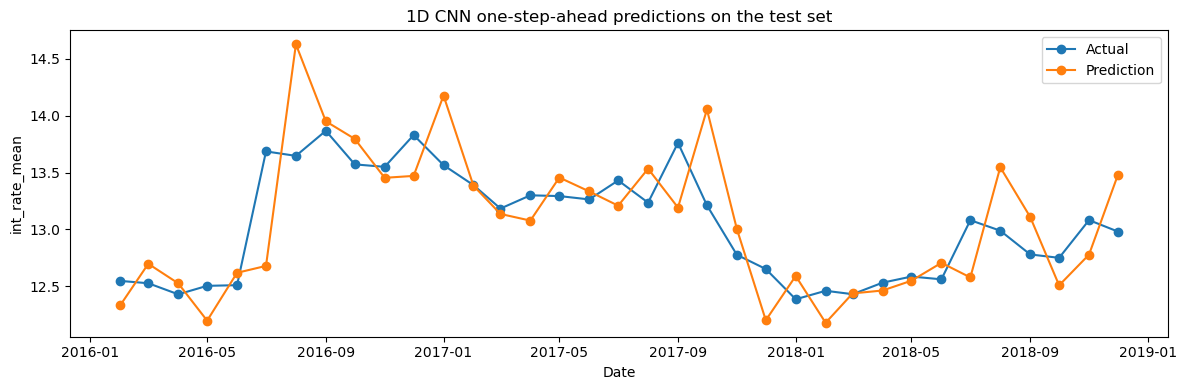

In [25]:
def fit_cnn(train_frame: pd.DataFrame, params: dict):
    seq_length = params["seq_length"]
    kernel_size = params["kernel_size"]

    if kernel_size > seq_length:
        raise ValueError("CNN kernel_size cannot be larger than seq_length.")
    if len(train_frame) <= seq_length + 2:
        raise ValueError("The train modeling frame is too short for the requested CNN sequence length.")

    split_idx = int(len(train_frame) * 0.85)
    train_split = train_frame.iloc[:split_idx].copy()
    val_split = train_frame.iloc[split_idx:].copy()

    if len(train_split) <= seq_length or len(val_split) <= seq_length:
        raise ValueError("Not enough rows in the train split / validation split for CNN sequence creation.")

    X_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_train = X_scaler.fit_transform(train_split[SEQUENCE_FEATURE_COLS])
    y_train = y_scaler.fit_transform(train_split[[TARGET_DIFF2_COL]])
    X_val = X_scaler.transform(val_split[SEQUENCE_FEATURE_COLS])
    y_val = y_scaler.transform(val_split[[TARGET_DIFF2_COL]])

    X_train_seq, y_train_seq = create_sequences(X_train, y_train, seq_length)
    X_val_seq, y_val_seq = create_sequences(X_val, y_val, seq_length)

    X_train_t = torch.tensor(X_train_seq, dtype=torch.float32)
    y_train_t = torch.tensor(y_train_seq.reshape(-1, 1), dtype=torch.float32)
    X_val_t = torch.tensor(X_val_seq, dtype=torch.float32)
    y_val_t = torch.tensor(y_val_seq.reshape(-1, 1), dtype=torch.float32)

    model = Tiny1DCNN(
        input_dim=X_train_t.shape[2],
        num_filters=params["num_filters"],
        kernel_size=params["kernel_size"],
        seq_length=params["seq_length"],
    )
    optimizer = optim.Adam(model.parameters(), lr=params["lr"])
    loss_fn = nn.HuberLoss()

    model = train_torch_model(
        model=model,
        X_train=X_train_t,
        y_train=y_train_t,
        X_val=X_val_t,
        y_val=y_val_t,
        optimizer=optimizer,
        loss_fn=loss_fn,
        max_epochs=params["max_epochs"],
        patience=params["patience"],
    )
    return model, X_scaler, y_scaler

def cnn_one_step_forecast(
    train_frame: pd.DataFrame,
    test_frame: pd.DataFrame,
    combined_model: pd.DataFrame,
    combined_ts: pd.DataFrame,
    transform_info: dict,
    params: dict,
) -> pd.DataFrame:
    model, X_scaler, y_scaler = fit_cnn(train_frame, params)
    seq_length = params["seq_length"]

    preds = []
    actuals = []

    for date in test_frame.index:
        current_pos = combined_model.index.get_loc(date)
        history_window = combined_model.iloc[current_pos - seq_length : current_pos][SEQUENCE_FEATURE_COLS]

        if len(history_window) != seq_length:
            raise ValueError(f"Insufficient history to create a CNN sequence for {date}.")

        X_test = X_scaler.transform(history_window)
        X_test_t = torch.tensor(X_test.reshape(1, seq_length, -1), dtype=torch.float32)

        model.eval()
        with torch.no_grad():
            pred_scaled = model(X_test_t).cpu().numpy().reshape(-1, 1)

        pred_diff2 = float(y_scaler.inverse_transform(pred_scaled)[0, 0])

        anchor_row = test_frame.loc[date]
        prediction = reconstruct_prediction(pred_diff2, anchor_row, transform_info)

        preds.append(float(prediction))
        actuals.append(float(combined_ts.loc[date, TARGET_COL]))

    return make_forecast_df(test_frame.index, actuals, preds, "CNN_1D")

cnn_results = cnn_one_step_forecast(
    train_frame=train_model,
    test_frame=test_model,
    combined_model=combined_model,
    combined_ts=combined_ts,
    transform_info=transform_info,
    params=CNN_PARAMS,
)

display(cnn_results.head())
print(summarize_forecasts(cnn_results))
plot_predictions(cnn_results, "1D CNN one-step-ahead predictions on the test set")

## 11. Compare all models on the test horizon

In [26]:
all_results = pd.concat(
    [
        sarimax_results,
        mlp_results,
        rnn_results,
        cnn_results,
    ],
    ignore_index=True,
)

test_summary = (
    all_results.groupby("model")
    .apply(lambda df: pd.Series(summarize_forecasts(df)))
    .reset_index()
    .sort_values(["RMSE", "MAE"])
    .reset_index(drop=True)
)

display(test_summary)


,model,RMSE,MAE,n_forecasts
0,"SARIMAX(2,0,1)",0.313541,0.220349,35.0
1,MLP,0.359538,0.273506,35.0
2,RNN_GRU,0.382019,0.296814,35.0
3,CNN_1D,0.395246,0.301591,35.0


## 12. Overlay plot for all predictions

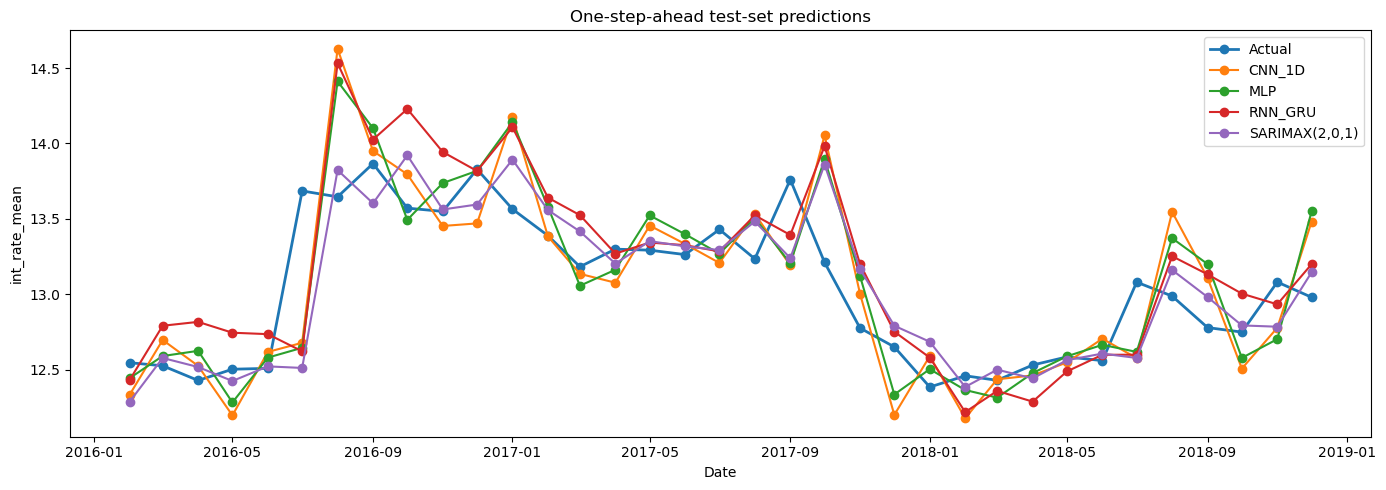

In [27]:
plt.figure(figsize=(14, 5))
actual_series = all_results.sort_values("date").drop_duplicates(subset=["date"], keep="first")
plt.plot(actual_series["date"], actual_series["actual"], marker="o", linewidth=2, label="Actual")

for model_name, model_df in all_results.groupby("model"):
    plot_df = model_df.sort_values("date")
    plt.plot(plot_df["date"], plot_df["prediction"], marker="o", label=model_name)

plt.title("One-step-ahead test-set predictions")
plt.xlabel("Date")
plt.ylabel(TARGET_COL)
plt.legend()
plt.tight_layout()
plt.show()


## 13. Save the outputs

This cell saves:
- one CSV with **all predictions**
- one CSV with the **metric summary**

In [28]:
OUTPUT_DIR = Path("./test_set_forecast_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

all_results.to_csv(OUTPUT_DIR / "all_test_predictions.csv", index=False)
test_summary.to_csv(OUTPUT_DIR / "test_summary.csv", index=False)

print(f"Saved: {OUTPUT_DIR / 'all_test_predictions.csv'}")
print(f"Saved: {OUTPUT_DIR / 'test_summary.csv'}")

Saved: test_set_forecast_outputs\all_test_predictions.csv
Saved: test_set_forecast_outputs\test_summary.csv
